# 🎨 Hands-On: Creating Your Own Visualizations

Welcome to your first data visualization coding experience!

> **▶️ Want to run this code yourself?** Open this notebook in Google Colab (free, no install needed): [**Open in Colab**](https://colab.research.google.com/github/tdbowman/110informatics.github.io/blob/main/module-07-visualization/hands-on-charts.ipynb). Or just read along — every chart's output is shown right here on the page. Don't worry if you've never written code before—this notebook will guide you step by step.

:::{tip} How to Use This Notebook
- **Read** the explanations in each section
- **Run** the code cells by clicking on them and pressing `Shift + Enter`
- **Experiment** by changing values and re-running cells
- **Don't worry about breaking anything**—you can always restart and try again!
:::

---

## Part 1: Setting Up

First, we need to import some tools. Think of this like getting your art supplies ready before painting.

Run the cell below (click on it, then press `Shift + Enter`):

In [1]:
# Import our visualization tools
import matplotlib.pyplot as plt
import pandas as pd

# Make our charts look nice
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All set! Your tools are ready.")

✅ All set! Your tools are ready.


---

## Part 2: Your First Bar Chart

Let's create a simple bar chart showing the most popular social media platforms.

*(The user numbers below are approximate figures from 2024. Platform rankings shift constantly — one of the exercises at the end asks you to look up the current numbers and update the chart. Data that goes stale is itself a data-visualization lesson!)*

### The Data

First, we'll create some data. In Python, we store data in structures called **lists**:

In [2]:
# Social media platforms
platforms = ['Facebook', 'YouTube', 'WhatsApp', 'Instagram', 'TikTok']

# Monthly active users (in billions)
users = [3.0, 2.5, 2.0, 2.0, 1.5]

print("Our data:")
for platform, user_count in zip(platforms, users):
    print(f"  {platform}: {user_count} billion users")

Our data:
  Facebook: 3.0 billion users
  YouTube: 2.5 billion users
  WhatsApp: 2.0 billion users
  Instagram: 2.0 billion users
  TikTok: 1.5 billion users


### Creating the Chart

Now let's turn this data into a visual bar chart:

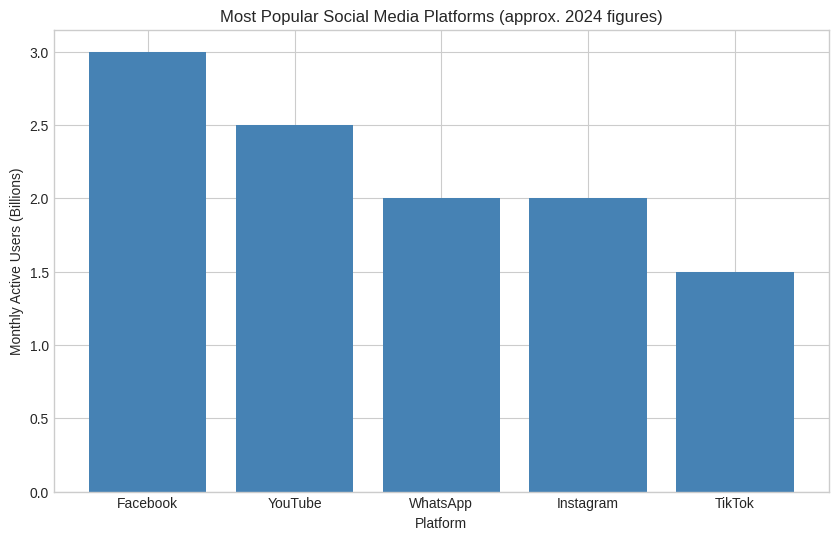

In [3]:
# Create the bar chart
plt.figure(figsize=(10, 6))  # Set the size
plt.bar(platforms, users, color='steelblue')

# Add labels and title
plt.xlabel('Platform')
plt.ylabel('Monthly Active Users (Billions)')
plt.title('Most Popular Social Media Platforms (approx. 2024 figures)')

# Display the chart
plt.show()

### 🎯 Try It Yourself!

In the cell below, change the `color` to a different color and run it again. Try: `'coral'`, `'seagreen'`, `'purple'`, or `'gold'`

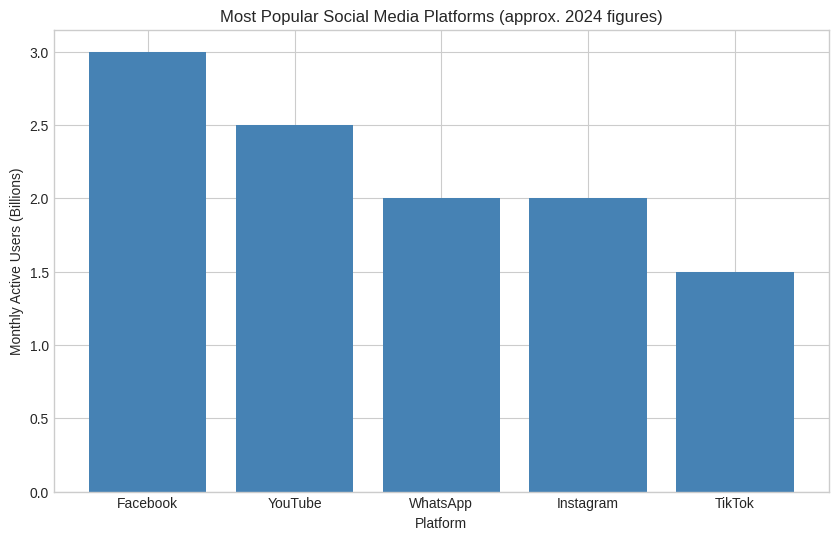

In [4]:
# YOUR TURN: Change the color below!
my_color = 'steelblue'  # <-- Change this!

plt.figure(figsize=(10, 6))
plt.bar(platforms, users, color=my_color)
plt.xlabel('Platform')
plt.ylabel('Monthly Active Users (Billions)')
plt.title('Most Popular Social Media Platforms (approx. 2024 figures)')
plt.show()

---

## Part 3: Line Charts for Trends

Line charts are perfect for showing how things change over time. Let's visualize smartphone adoption over the years:

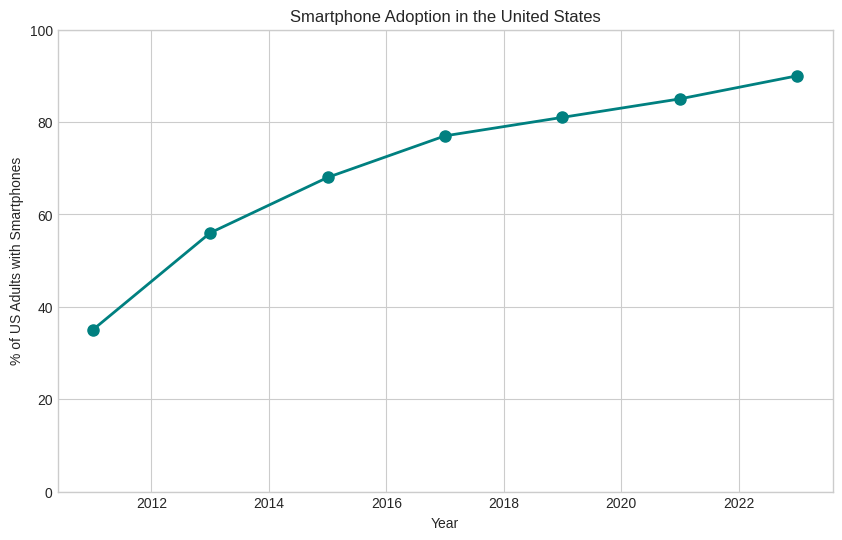

In [5]:
# Data: Percentage of US adults with smartphones
years = [2011, 2013, 2015, 2017, 2019, 2021, 2023]
smartphone_adoption = [35, 56, 68, 77, 81, 85, 90]

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(years, smartphone_adoption, marker='o', linewidth=2, markersize=8, color='teal')

# Add labels
plt.xlabel('Year')
plt.ylabel('% of US Adults with Smartphones')
plt.title('Smartphone Adoption in the United States')

# Set y-axis to start at 0 (important for honest visualization!)
plt.ylim(0, 100)

plt.show()

### ⚠️ Visualization Ethics: The Truncated Y-Axis

Watch what happens when we DON'T start the y-axis at zero:

/tmp/ipykernel_10415/776358316.py:17: UserWarning: Glyph 128561 (\N{FACE SCREAMING IN FEAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_10415/776358316.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128561 (\N{FACE SCREAMING IN FEAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


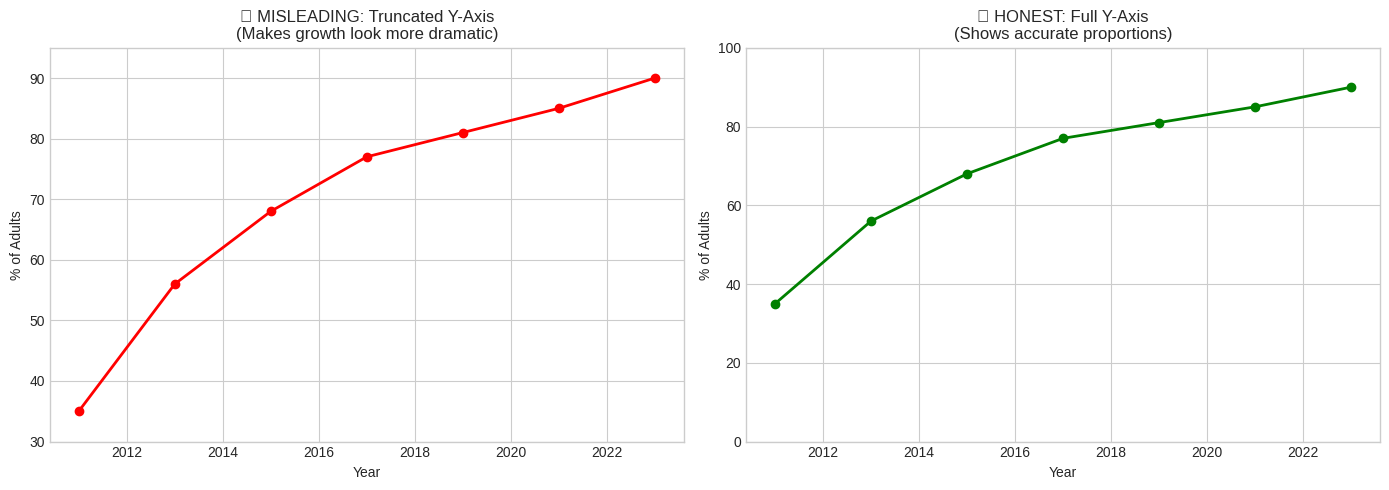

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MISLEADING: Truncated y-axis
axes[0].plot(years, smartphone_adoption, marker='o', linewidth=2, color='red')
axes[0].set_ylim(30, 95)  # Starts at 30, not 0!
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% of Adults')
axes[0].set_title('😱 MISLEADING: Truncated Y-Axis\n(Makes growth look more dramatic)')

# HONEST: Full y-axis
axes[1].plot(years, smartphone_adoption, marker='o', linewidth=2, color='green')
axes[1].set_ylim(0, 100)  # Starts at 0
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Adults')
axes[1].set_title('✅ HONEST: Full Y-Axis\n(Shows accurate proportions)')

plt.tight_layout()
plt.show()

Both charts show the exact same data! But they tell very different stories. The left chart makes it look like smartphone adoption exploded, while the right chart shows steady, gradual growth. 

This is why being a critical consumer of visualizations matters!

---

## Part 4: Working with Real Data

Let's work with a real dataset! We'll use data about passengers on the Titanic—a classic dataset for learning data analysis.

In [7]:
# Load the Titanic dataset
# (We keep a copy in this book's repository; if you're running in Colab, it falls back to the web.)
try:
    titanic = pd.read_csv('../data/titanic.csv')
except FileNotFoundError:
    titanic = pd.read_csv('https://raw.githubusercontent.com/tdbowman/110informatics.github.io/main/data/titanic.csv')

# Let's see what we're working with
print(f"This dataset has {len(titanic)} passengers and {len(titanic.columns)} columns of information.")
print("\nFirst few rows:")
titanic.head()

This dataset has 891 passengers and 12 columns of information.

First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploring the Data with Visualizations

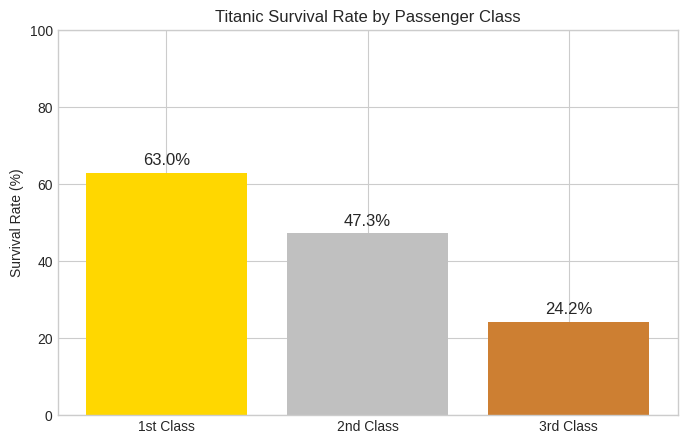

In [8]:
# Survival by passenger class
survival_by_class = titanic.groupby('Pclass')['Survived'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(['1st Class', '2nd Class', '3rd Class'], survival_by_class.values, 
               color=['gold', 'silver', '#cd7f32'])  # Gold, silver, bronze colors
plt.ylabel('Survival Rate (%)')
plt.title('Titanic Survival Rate by Passenger Class')
plt.ylim(0, 100)

# Add percentage labels on bars
for bar, pct in zip(bars, survival_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{pct:.1f}%', ha='center', fontsize=12)

plt.show()

This visualization reveals a stark reality: your socioeconomic class significantly affected your chances of survival on the Titanic. First-class passengers had nearly double the survival rate of third-class passengers. 

This is informatics in action—data visualization helping us see patterns and inequities that might be hidden in raw numbers.

---

## 🤖 Bonus: Put an AI to the Test

You've now made charts by hand — which means you're qualified to *grade* an AI's charts.

**Try this:** Ask an AI assistant (ChatGPT, Claude, Copilot...) to create a bar chart of the social media data from Part 2. Then critique its output like a chart detective:

1. Did it pick an appropriate chart type?
2. Are the axes labeled? Does the y-axis start at zero?
3. Did it *invent* any numbers you didn't give it?
4. Is its chart clearer than yours — or just shinier?

Also try asking it to update the chart with **current** platform user numbers, and then verify those numbers against a real source. This workflow — *AI drafts, human verifies* — is exactly how visualization pros use these tools.


---

## 🎉 Congratulations!

You've just created your first data visualizations using Python! Here's what you learned:

- ✅ How to create bar charts for comparisons
- ✅ How to create line charts for trends over time  
- ✅ How to spot misleading visualizations (truncated y-axes)
- ✅ How to work with real data

:::{tip} For Your Reflection
Consider writing about your experience with this notebook in your weekly reflection:
- What surprised you about creating visualizations with code?
- How did seeing the "misleading vs. honest" chart comparison change how you'll look at visualizations?
- What story did the Titanic data tell you through these visualizations?
:::